In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/LADOT_Traffic_Counts_Summary_20260515.csv")

# Check dataset shape
print("Dataset Shape:", df.shape)

# Show first 5 rows
df.head()

Dataset Shape: (5953, 12)


,Primary Street,Dir,Cross Street,Type,Dist,Count Date,Day,W/B,E/B,N/B,S/B,Total
0,1 st ST,AT,MC CADDEN PL,AUT,TUE,"February 05, 2013",TUE,364,763,0,0,"1,127"
1,1 st ST,AT,ALAMEDA ST,AUTO,CR,"January 16, 2014",THU,"6,433","11,669",0,0,"18,102"
2,1 st ST,AT,MAIN ST,MIO,CR,"March 27, 2013",WED,"9,221","9,811",0,0,"19,032"
3,1 st ST,AT,SPRING ST,MIO,CR,"March 19, 2013",TUE,"9,365","9,884",0,0,"19,249"
4,1 st ST,AT,MAIN ST,MAN,CR,"November 08, 2011",TUE,"11,400","12,497",NaN,NaN,"23,897"


In [ ]:
# Check missing values
print("Missing Values:\n")
print(df.isnull().sum())

print("\n\nData Types:\n")
print(df.dtypes)

Missing Values:

Primary Street      0
Dir                16
Cross Street        0
Type                0
Dist                0
Count Date          6
Day                 0
W/B               843
E/B               838
N/B               714
S/B               736
Total               9
dtype: int64


Data Types:

Primary Street    object
Dir               object
Cross Street      object
Type              object
Dist              object
Count Date        object
Day               object
W/B               object
E/B               object
N/B               object
S/B               object
Total             object
dtype: object


In [ ]:

# Columns that should be numeric
traffic_cols = ['W/B', 'E/B', 'N/B', 'S/B', 'Total']

# Remove commas and convert to numeric
for col in traffic_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
    )

    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check updated data types
print(df[traffic_cols].dtypes)

# Preview cleaned columns
df[traffic_cols].head()

W/B      float64
E/B      float64
N/B      float64
S/B      float64
Total    float64
dtype: object


,W/B,E/B,N/B,S/B,Total
0,364.0,763.0,0.0,0.0,1127.0
1,6433.0,11669.0,0.0,0.0,18102.0
2,9221.0,9811.0,0.0,0.0,19032.0
3,9365.0,9884.0,0.0,0.0,19249.0
4,11400.0,12497.0,NaN,NaN,23897.0


In [ ]:

# Fill missing traffic counts with 0
traffic_cols = ['W/B', 'E/B', 'N/B', 'S/B', 'Total']

df[traffic_cols] = df[traffic_cols].fillna(0)

# Check missing values again
print(df[traffic_cols].isnull().sum())

# Preview cleaned data
df[traffic_cols].head()

W/B      0
E/B      0
N/B      0
S/B      0
Total    0
dtype: int64


,W/B,E/B,N/B,S/B,Total
0,364.0,763.0,0.0,0.0,1127.0
1,6433.0,11669.0,0.0,0.0,18102.0
2,9221.0,9811.0,0.0,0.0,19032.0
3,9365.0,9884.0,0.0,0.0,19249.0
4,11400.0,12497.0,0.0,0.0,23897.0


In [ ]:

# Convert Count Date safely
df['Count Date'] = pd.to_datetime(df['Count Date'], errors='coerce')

# Check how many invalid dates became NaT
print("Invalid dates:", df['Count Date'].isnull().sum())

# Show rows with invalid dates
df[df['Count Date'].isnull()].head()

Invalid dates: 7


,Primary Street,Dir,Cross Street,Type,Dist,Count Date,Day,W/B,E/B,N/B,S/B,Total
640,BRONSON AV,AT,FERNWOOD AV,MAN,HW,NaT,THU,0.0,0.0,3734.0,4406.0,8140.0
2805,WEST BL,S/O,PICO BL,AUTO,EV,NaT,TUE,0.0,0.0,825.0,1161.0,1986.0
3040,GLENHURST AV,AT,GARDEN AV,MAN,HW,NaT,WED,660.0,703.0,0.0,0.0,1363.0
3041,AVE 64,AT,ELGIN ST,AUTO,CR,NaT,WED,0.0,0.0,5666.0,5461.0,11127.0
3500,INGLEWOOD BL,N/O,BEATRICE ST,AUTO,WR,NaT,TUE,0.0,0.0,8045.0,9199.0,17244.0


In [ ]:

# Remove rows with invalid dates
df = df.dropna(subset=['Count Date'])

# Check remaining rows
print("New dataset shape:", df.shape)

New dataset shape: (5946, 12)


In [ ]:

# Create time-based features
df['Year'] = df['Count Date'].dt.year
df['Month'] = df['Count Date'].dt.month
df['Day_Number'] = df['Count Date'].dt.day

# Create weekend feature
df['Is_Weekend'] = df['Day'].isin(['SAT', 'SUN'])

# Create directional average
df['Directional_Avg'] = df[['W/B', 'E/B', 'N/B', 'S/B']].mean(axis=1)

# Create congestion index
df['Congestion_Index'] = df['Total'] / (df['Directional_Avg'] + 1)

# Preview
df[['Count Date', 'Year', 'Month', 'Day',
    'Is_Weekend', 'Directional_Avg',
    'Congestion_Index']].head()

,Count Date,Year,Month,Day,Is_Weekend,Directional_Avg,Congestion_Index
0,2013-02-05,2013,2,TUE,False,281.75,3.985853
1,2014-01-16,2014,1,THU,False,4525.50,3.999116
2,2013-03-27,2013,3,WED,False,4758.00,3.999159
3,2013-03-19,2013,3,TUE,False,4812.25,3.999169
4,2011-11-08,2011,11,TUE,False,5974.25,3.999331


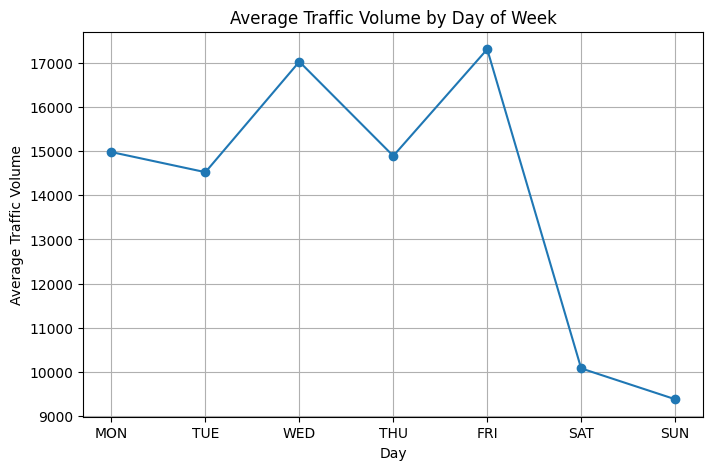

In [ ]:

import matplotlib.pyplot as plt

# Average traffic by day
day_traffic = df.groupby('Day')['Total'].mean()

# Order weekdays properly
ordered_days = ['MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT', 'SUN']
day_traffic = day_traffic.reindex(ordered_days)

# Create chart
plt.figure(figsize=(8,5))
plt.plot(day_traffic.index, day_traffic.values, marker='o')

plt.title('Average Traffic Volume by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Traffic Volume')

plt.grid(True)

plt.show()

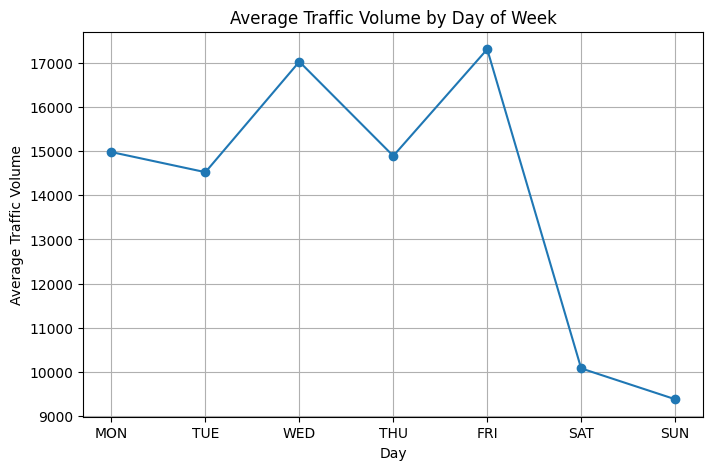

In [ ]:

plt.figure(figsize=(8,5))
plt.plot(day_traffic.index, day_traffic.values, marker='o')

plt.title('Average Traffic Volume by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Traffic Volume')

plt.grid(True)

# Save figure
plt.savefig('traffic_by_day.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Features
X = df[['W/B', 'E/B', 'N/B', 'S/B']]

# Target
y = df['Total']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Absolute Error: 718.4767945395288
R² Score: 0.9859875379679885


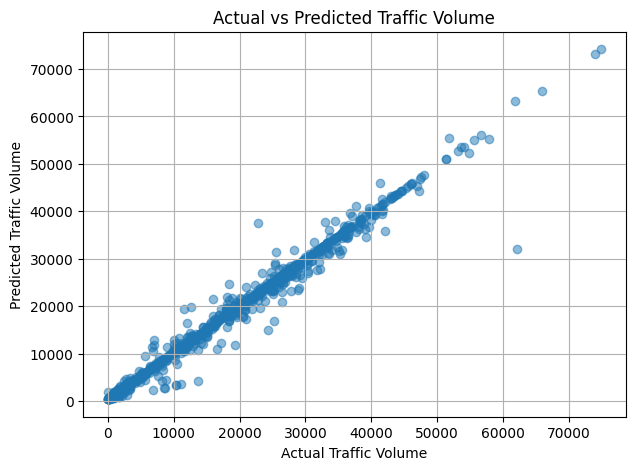

In [ ]:

import matplotlib.pyplot as plt

# Scatter plot
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")

plt.title("Actual vs Predicted Traffic Volume")

plt.grid(True)

plt.show()

In [ ]:

# Create congestion categories using quantiles

df['Congestion_Level'] = pd.qcut(
    df['Congestion_Index'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# Check class counts
print(df['Congestion_Level'].value_counts())

Congestion_Level
Low       1982
Medium    1982
High      1982
Name: count, dtype: int64


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Features
X = df[['W/B', 'E/B', 'N/B', 'S/B', 'Total']]

# Target
y = df['Congestion_Level']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.992436974789916

Classification Report:

              precision    recall  f1-score   support

        High       0.99      0.99      0.99       397
         Low       1.00      0.99      0.99       401
      Medium       0.99      1.00      0.99       392

    accuracy                           0.99      1190
   macro avg       0.99      0.99      0.99      1190
weighted avg       0.99      0.99      0.99      1190


Confusion Matrix:

[[395   0   2]
 [  3 395   3]
 [  1   0 391]]


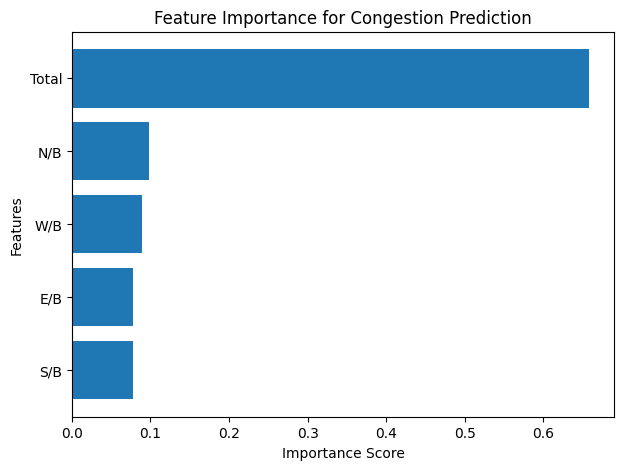

In [ ]:

import matplotlib.pyplot as plt
import pandas as pd

# Feature importance
importance = rf_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=True
)

# Plot
plt.figure(figsize=(7,5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.title('Feature Importance for Congestion Prediction')

plt.show()

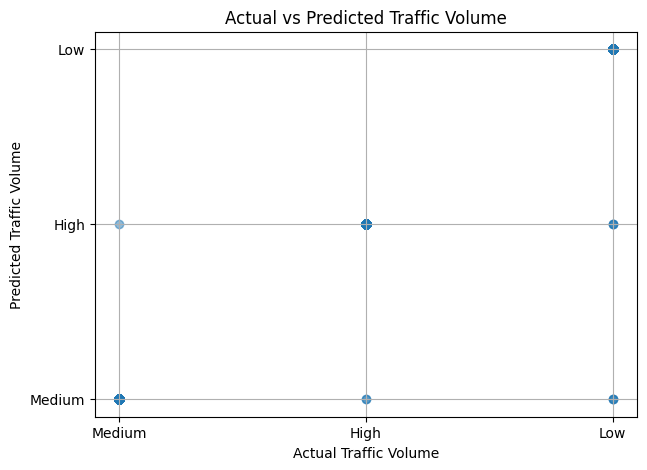

In [ ]:

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")

plt.title("Actual vs Predicted Traffic Volume")

plt.grid(True)

plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches='tight')

plt.show()

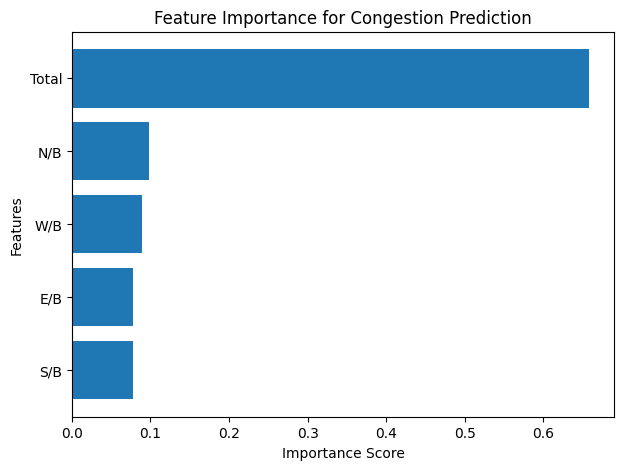

In [ ]:

plt.figure(figsize=(7,5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.title('Feature Importance for Congestion Prediction')

plt.savefig("feature_importance.png", dpi=300, bbox_inches='tight')

plt.show()

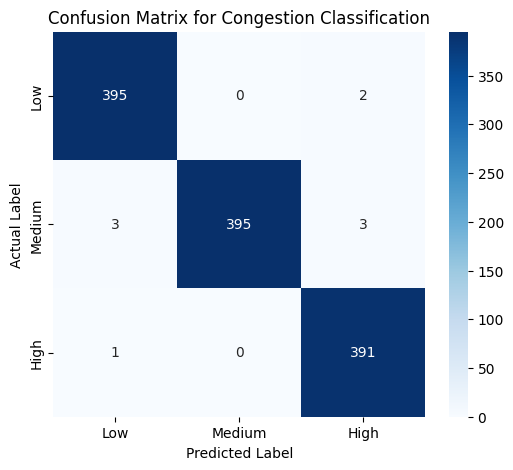

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.title("Confusion Matrix for Congestion Classification")

plt.show()

In [ ]:
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

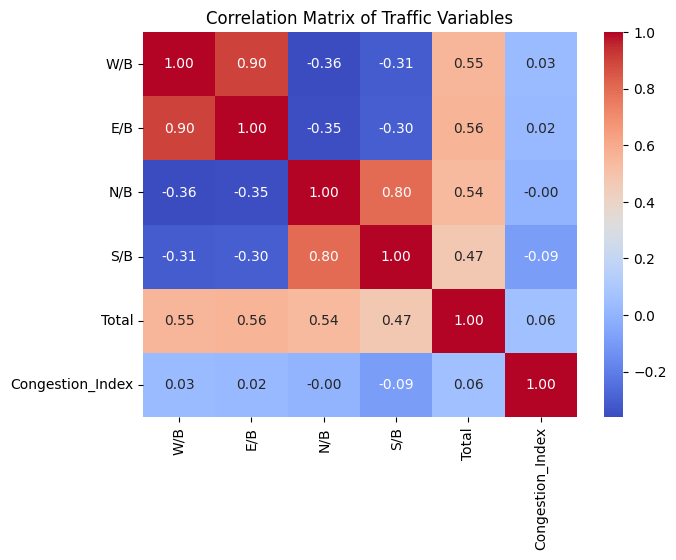

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
corr_cols = ['W/B', 'E/B', 'N/B', 'S/B', 'Total', 'Congestion_Index']

# Correlation matrix
corr_matrix = df[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(7,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Traffic Variables')

plt.show()

In [ ]:
plt.savefig("correlation_matrix.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Features WITHOUT Total
X = df[['W/B', 'E/B', 'N/B', 'S/B']]

# Target
y = df['Congestion_Level']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Random Forest model
rf_model_no_total = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model_no_total.fit(X_train, y_train)

# Predict
y_pred_no_total = rf_model_no_total.predict(X_test)

# Evaluation
accuracy_no_total = accuracy_score(y_test, y_pred_no_total)

print("Accuracy without Total:", accuracy_no_total)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_no_total))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_no_total))

Accuracy without Total: 0.9840336134453781

Classification Report:

              precision    recall  f1-score   support

        High       0.99      0.99      0.99       397
         Low       0.99      0.97      0.98       401
      Medium       0.97      0.99      0.98       392

    accuracy                           0.98      1190
   macro avg       0.98      0.98      0.98      1190
weighted avg       0.98      0.98      0.98      1190


Confusion Matrix:

[[393   0   4]
 [  3 389   9]
 [  1   2 389]]


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode Day column
le = LabelEncoder()
df['Day_Encoded'] = le.fit_transform(df['Day'])

# Features with temporal variables
X = df[['W/B', 'E/B', 'N/B', 'S/B',
        'Month', 'Is_Weekend', 'Day_Encoded']]

# Target
y = df['Congestion_Level']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Encode the 'Day' column
le = LabelEncoder()
df['Day_Encoded'] = le.fit_transform(df['Day'])

# Features (including traffic and time-related)
X = df[['W/B', 'E/B', 'N/B', 'S/B', 'Month', 'Is_Weekend', 'Day_Encoded']]

# Target (Congestion Level)
y = df['Congestion_Level']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9840

Classification Report:

              precision    recall  f1-score   support

        High       0.99      0.99      0.99       397
         Low       1.00      0.97      0.98       401
      Medium       0.97      0.99      0.98       392

    accuracy                           0.98      1190
   macro avg       0.98      0.98      0.98      1190
weighted avg       0.98      0.98      0.98      1190


Confusion Matrix:

[[394   0   3]
 [  3 388  10]
 [  2   1 389]]
